In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Retail Data.csv')
df

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,4293-1,02-09-2014,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,$156.50,$300.97,$144.47,23.0,"$4,533.52",2%,$194.83,"$4,757.22",$7.18,"$4,291.55"
1,5001-1,24-10-2015,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,$0.24,$1.26,$1.02,8.0,$45.20,3%,$0.00,$45.90,$0.70,$46.91
2,5004-1,13-03-2014,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,$42.11,$80.98,$38.87,45.0,$873.32,4%,$72.23,$837.57,$7.18,$82.58
3,5009-1,18-02-2013,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,$5.33,$8.60,$3.27,16.0,$73.52,1%,$4.35,$740.67,$6.19,$730.92
4,5010-1,13-09-2014,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,$1.53,$2.78,$1.25,49.0,$138.46,7%,$5.95,$123.77,$1.34,$125.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6831-1,02-11-2016,Roland Murray,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Critical,Artisan Hi-Liter Smear-Safe Highlighters,...,$2.98,$5.84,$2.86,35.0,$115.40,2%,$10.81,$104.09,$0.83,$101.22
4996,6847-1,16-12-2015,Patrick OBrill,"63 Riley Street,Woolloomooloo",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Smiths Colored Interoffice Envelopes,...,$19.83,$30.98,$11.15,49.0,"$1,999.69",7%,$143.91,"$1,947.75",$19.51,"$1,052.55"
4997,6922-1,28-09-2016,Troy Staebel,"1-2/299 Sussex St,Sydney",Sydney,NSW,Consumer,Aanya Zhang,Low,Laser DVD-RAM discs,...,$20.18,$35.41,$15.23,19.0,$929.40,9%,$27.88,$901.52,$1.99,$921.03
4998,6939-1,18-06-2016,Shaun Weien,"Shop 3/144 Wattle St,Ultimo",Sydney,NSW,Corporate,Samantha Chairs,Not Specified,Artisan 479 Labels,...,$1.59,$2.61,$1.02,23.0,$66.54,5%,$4.46,$63.77,$0.50,$64.27


In [43]:
df.columns

Index(['Order No', 'Order Date', 'Customer Name', 'Address', 'City', 'State',
       'Customer Type', 'Account Manager', 'Order Priority', 'Product Name',
       'Product Category', 'Product Container', 'Ship Mode', 'Ship Date',
       'Cost Price', 'Retail Price', 'Profit Margin', 'Order Quantity',
       'Sub Total', 'Discount %', 'Discount $', 'Order Total', 'Shipping Cost',
       'Total'],
      dtype='object')

## 1. View the structure of the dataset (columns, types, missing values)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order No           5000 non-null   object 
 1   Order Date         5000 non-null   object 
 2   Customer Name      5000 non-null   object 
 3   Address            4999 non-null   object 
 4   City               5000 non-null   object 
 5   State              5000 non-null   object 
 6   Customer Type      5000 non-null   object 
 7   Account Manager    5000 non-null   object 
 8   Order Priority     5000 non-null   object 
 9   Product Name       5000 non-null   object 
 10  Product Category   5000 non-null   object 
 11  Product Container  5000 non-null   object 
 12  Ship Mode          5000 non-null   object 
 13  Ship Date          5000 non-null   object 
 14  Cost Price         5000 non-null   object 
 15  Retail Price       5000 non-null   object 
 16  Profit Margin      5000 

In [45]:
df.isnull().sum()

Order No             0
Order Date           0
Customer Name        0
Address              1
City                 0
State                0
Customer Type        0
Account Manager      0
Order Priority       0
Product Name         0
Product Category     0
Product Container    0
Ship Mode            0
Ship Date            0
Cost Price           0
Retail Price         0
Profit Margin        0
Order Quantity       1
Sub Total            0
Discount %           0
Discount $           0
Order Total          0
Shipping Cost        0
Total                0
dtype: int64

In [46]:
df[df.isna().any(axis=1)]

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
1411,5428-1,25-02-2014,Jhrip Luxen,"4A Lyons St,Strathfield",Sydney,NSW,Home Office,Tina Carlton,High,Creator Colored Pencils,...,$1.57,$3.28,$1.71,NaN,$85.28,4%,$6.82,$78.46,$0.98,$79.44
4354,6384-1,27-04-2016,Patt Bawkins,NaN,Sydney,NSW,Small Business,Tina Carlton,High,HFX LaserJet 3310 Copier,...,$377.99,$599.99,$222.00,47.0,"$9,599.84",0%,$0.00,"$9,599.84",$24.49,"$9,624.33"


### There are Two Null values
### First one is 1411 index where Address is null
### Second one is 4354 index where Order Quantity is missing

In [47]:
df.shape

(5000, 24)

## 3. Are there any duplicate records?

In [48]:
df.duplicated().sum()

np.int64(0)

### No Duplicate value

## 4. Are there any missing or corrupted entries in Ship Date, Order Date, or numeric columns?


In [49]:
df.convert_dtypes()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order No           5000 non-null   object 
 1   Order Date         5000 non-null   object 
 2   Customer Name      5000 non-null   object 
 3   Address            4999 non-null   object 
 4   City               5000 non-null   object 
 5   State              5000 non-null   object 
 6   Customer Type      5000 non-null   object 
 7   Account Manager    5000 non-null   object 
 8   Order Priority     5000 non-null   object 
 9   Product Name       5000 non-null   object 
 10  Product Category   5000 non-null   object 
 11  Product Container  5000 non-null   object 
 12  Ship Mode          5000 non-null   object 
 13  Ship Date          5000 non-null   object 
 14  Cost Price         5000 non-null   object 
 15  Retail Price       5000 non-null   object 
 16  Profit Margin      5000 

In [50]:
df.describe()

,Order Quantity
count,4999.000000
mean,26.483097
std,14.391863
min,1.000000
25%,13.000000
50%,27.000000
75%,39.000000
max,50.000000


## 5. Convert Order Date and Ship Date to datetime.

In [51]:
df[['Order Date','Ship Date']] = df[['Order Date','Ship Date']].apply(pd.to_datetime, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order No           5000 non-null   object        
 1   Order Date         1903 non-null   datetime64[ns]
 2   Customer Name      5000 non-null   object        
 3   Address            4999 non-null   object        
 4   City               5000 non-null   object        
 5   State              5000 non-null   object        
 6   Customer Type      5000 non-null   object        
 7   Account Manager    5000 non-null   object        
 8   Order Priority     5000 non-null   object        
 9   Product Name       5000 non-null   object        
 10  Product Category   5000 non-null   object        
 11  Product Container  5000 non-null   object        
 12  Ship Mode          5000 non-null   object        
 13  Ship Date          1832 non-null   datetime64[ns]
 14  Cost Pri

## 6. Check for future or inconsistent shipping dates.

In [52]:
df.loc[df['Ship Date'] > pd.Timestamp.now(), 'date_issue'] = 'Future Date'
df

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total,date_issue
0,4293-1,2014-02-09,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,$300.97,$144.47,23.0,"$4,533.52",2%,$194.83,"$4,757.22",$7.18,"$4,291.55",NaN
1,5001-1,NaT,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,$1.26,$1.02,8.0,$45.20,3%,$0.00,$45.90,$0.70,$46.91,NaN
2,5004-1,NaT,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,$80.98,$38.87,45.0,$873.32,4%,$72.23,$837.57,$7.18,$82.58,NaN
3,5009-1,NaT,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,$8.60,$3.27,16.0,$73.52,1%,$4.35,$740.67,$6.19,$730.92,NaN
4,5010-1,NaT,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,$2.78,$1.25,49.0,$138.46,7%,$5.95,$123.77,$1.34,$125.97,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6831-1,2016-02-11,Roland Murray,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Critical,Artisan Hi-Liter Smear-Safe Highlighters,...,$5.84,$2.86,35.0,$115.40,2%,$10.81,$104.09,$0.83,$101.22,NaN
4996,6847-1,NaT,Patrick OBrill,"63 Riley Street,Woolloomooloo",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Smiths Colored Interoffice Envelopes,...,$30.98,$11.15,49.0,"$1,999.69",7%,$143.91,"$1,947.75",$19.51,"$1,052.55",NaN
4997,6922-1,NaT,Troy Staebel,"1-2/299 Sussex St,Sydney",Sydney,NSW,Consumer,Aanya Zhang,Low,Laser DVD-RAM discs,...,$35.41,$15.23,19.0,$929.40,9%,$27.88,$901.52,$1.99,$921.03,NaN
4998,6939-1,NaT,Shaun Weien,"Shop 3/144 Wattle St,Ultimo",Sydney,NSW,Corporate,Samantha Chairs,Not Specified,Artisan 479 Labels,...,$2.61,$1.02,23.0,$66.54,5%,$4.46,$63.77,$0.50,$64.27,NaN


## 7. Convert price columns to numeric (remove $ and commas).

In [53]:
df = df.astype({'Retail Price': 'string', 'Profit Margin': 'string','Sub Total': 'string','Discount $':'string','Order Total':'string',	'Shipping Cost':'string', 'Total':'string'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order No           5000 non-null   object        
 1   Order Date         1903 non-null   datetime64[ns]
 2   Customer Name      5000 non-null   object        
 3   Address            4999 non-null   object        
 4   City               5000 non-null   object        
 5   State              5000 non-null   object        
 6   Customer Type      5000 non-null   object        
 7   Account Manager    5000 non-null   object        
 8   Order Priority     5000 non-null   object        
 9   Product Name       5000 non-null   object        
 10  Product Category   5000 non-null   object        
 11  Product Container  5000 non-null   object        
 12  Ship Mode          5000 non-null   object        
 13  Ship Date          1832 non-null   datetime64[ns]
 14  Cost Pri

In [54]:

df['Sub Total'] = df['Sub Total'].replace(r'[$,]', '', regex=True).astype(float)
df['Discount $'] = df['Discount $'].replace(r'[$,]', '', regex=True).astype(float)
df['Order Total'] = df['Order Total'].replace(r'[$,]', '', regex=True).astype(float)
df['Shipping Cost'] = df['Shipping Cost'].replace(r'[$,]', '', regex=True).astype(float)
df['Total'] = df['Total'].replace(r'[$,]', '', regex=True).astype(float)
df['Discount %'] = df['Discount %'].replace({r'\%': ''},regex=True).astype(float)

In [55]:
df['Profit Margin'] = df['Profit Margin'].replace(r'[$,]', '', regex=True).astype(float)
df['Retail Price'] = df['Retail Price'].replace(r'[$,]', '', regex=True).astype(float)
df['Cost Price'] = df['Cost Price'].replace(r'[$,]', '', regex=True).astype(float)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order No           5000 non-null   object        
 1   Order Date         1903 non-null   datetime64[ns]
 2   Customer Name      5000 non-null   object        
 3   Address            4999 non-null   object        
 4   City               5000 non-null   object        
 5   State              5000 non-null   object        
 6   Customer Type      5000 non-null   object        
 7   Account Manager    5000 non-null   object        
 8   Order Priority     5000 non-null   object        
 9   Product Name       5000 non-null   object        
 10  Product Category   5000 non-null   object        
 11  Product Container  5000 non-null   object        
 12  Ship Mode          5000 non-null   object        
 13  Ship Date          1832 non-null   datetime64[ns]
 14  Cost Pri

## 8. What are the unique values in Customer Type and Order Priority?

In [57]:
df['Customer Type'].unique()

array(['Small Business', 'Corporate', 'Consumer', 'Home Office'],
      dtype=object)

In [58]:
df['Order Priority'].unique()

array(['Critical', 'Medium', 'Not Specified', 'Low', 'High'], dtype=object)

## 9. What are the most common shipping modes?

In [59]:
df['Ship Mode'].mode().sum()

'Regular Air'

## 10. Which cities have the highest number of orders?

In [60]:
df['City'].value_counts()

City
Sydney       3584
Melbourne    1416
Name: count, dtype: int64

#### Sydney has highest Number of Order

## 11. What’s the range of order quantities and prices?

In [61]:
Min_Order = df['Order Quantity'].min()
Max_Order = df['Order Quantity'].max()
print(f'Order Range:{Min_Order} to {Max_Order}')
Min_Price = df['Retail Price'].min()
Max_Price = df['Retail Price'].max()
print(f'Order Range:{Min_Price} to {Max_Price}')

Order Range:1.0 to 50.0
Order Range:1.14 to 599.99


## 12. Create a new column for shipping duration.

In [62]:
df['Ship Duration'] = df['Order Date']-df['Ship Date']
df

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total,date_issue,Ship Duration
0,4293-1,2014-02-09,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,144.47,23.0,4533.52,2.0,194.83,4757.22,7.18,4291.55,NaN,-59 days
1,5001-1,NaT,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,1.02,8.0,45.20,3.0,0.00,45.90,0.70,46.91,NaN,NaT
2,5004-1,NaT,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,38.87,45.0,873.32,4.0,72.23,837.57,7.18,82.58,NaN,NaT
3,5009-1,NaT,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,3.27,16.0,73.52,1.0,4.35,740.67,6.19,730.92,NaN,NaT
4,5010-1,NaT,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,1.25,49.0,138.46,7.0,5.95,123.77,1.34,125.97,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6831-1,2016-02-11,Roland Murray,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Critical,Artisan Hi-Liter Smear-Safe Highlighters,...,2.86,35.0,115.40,2.0,10.81,104.09,0.83,101.22,NaN,-121 days
4996,6847-1,NaT,Patrick OBrill,"63 Riley Street,Woolloomooloo",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Smiths Colored Interoffice Envelopes,...,11.15,49.0,1999.69,7.0,143.91,1947.75,19.51,1052.55,NaN,NaT
4997,6922-1,NaT,Troy Staebel,"1-2/299 Sussex St,Sydney",Sydney,NSW,Consumer,Aanya Zhang,Low,Laser DVD-RAM discs,...,15.23,19.0,929.40,9.0,27.88,901.52,1.99,921.03,NaN,NaT
4998,6939-1,NaT,Shaun Weien,"Shop 3/144 Wattle St,Ultimo",Sydney,NSW,Corporate,Samantha Chairs,Not Specified,Artisan 479 Labels,...,1.02,23.0,66.54,5.0,4.46,63.77,0.50,64.27,NaN,NaT


## 13. Are there any orders with zero or negative total or quantity?

In [63]:
df1 = df[(df['Total'] <= 0) | (df['Order Quantity'] <= 0)]
df1

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total,date_issue,Ship Duration


#### There are no negetive or Zero Quantity or Total

## 14. Are all discount percentages matching discount dollar amounts?

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype          
---  ------             --------------  -----          
 0   Order No           5000 non-null   object         
 1   Order Date         1903 non-null   datetime64[ns] 
 2   Customer Name      5000 non-null   object         
 3   Address            4999 non-null   object         
 4   City               5000 non-null   object         
 5   State              5000 non-null   object         
 6   Customer Type      5000 non-null   object         
 7   Account Manager    5000 non-null   object         
 8   Order Priority     5000 non-null   object         
 9   Product Name       5000 non-null   object         
 10  Product Category   5000 non-null   object         
 11  Product Container  5000 non-null   object         
 12  Ship Mode          5000 non-null   object         
 13  Ship Date          1832 non-null   datetime64[ns

In [65]:
df[['Cost Price','Retail Price']]

,Cost Price,Retail Price
0,156.50,300.97
1,0.24,1.26
2,42.11,80.98
3,5.33,8.60
4,1.53,2.78
...,...,...
4995,2.98,5.84
4996,19.83,30.98
4997,20.18,35.41
4998,1.59,2.61


In [66]:
df['Discount'] = (df['Discount %'] / 100) * df['Sub Total']
df

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total,date_issue,Ship Duration,Discount
0,4293-1,2014-02-09,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,23.0,4533.52,2.0,194.83,4757.22,7.18,4291.55,NaN,-59 days,90.6704
1,5001-1,NaT,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,8.0,45.20,3.0,0.00,45.90,0.70,46.91,NaN,NaT,1.3560
2,5004-1,NaT,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,45.0,873.32,4.0,72.23,837.57,7.18,82.58,NaN,NaT,34.9328
3,5009-1,NaT,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,16.0,73.52,1.0,4.35,740.67,6.19,730.92,NaN,NaT,0.7352
4,5010-1,NaT,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,49.0,138.46,7.0,5.95,123.77,1.34,125.97,NaN,NaT,9.6922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6831-1,2016-02-11,Roland Murray,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Critical,Artisan Hi-Liter Smear-Safe Highlighters,...,35.0,115.40,2.0,10.81,104.09,0.83,101.22,NaN,-121 days,2.3080
4996,6847-1,NaT,Patrick OBrill,"63 Riley Street,Woolloomooloo",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Smiths Colored Interoffice Envelopes,...,49.0,1999.69,7.0,143.91,1947.75,19.51,1052.55,NaN,NaT,139.9783
4997,6922-1,NaT,Troy Staebel,"1-2/299 Sussex St,Sydney",Sydney,NSW,Consumer,Aanya Zhang,Low,Laser DVD-RAM discs,...,19.0,929.40,9.0,27.88,901.52,1.99,921.03,NaN,NaT,83.6460
4998,6939-1,NaT,Shaun Weien,"Shop 3/144 Wattle St,Ultimo",Sydney,NSW,Corporate,Samantha Chairs,Not Specified,Artisan 479 Labels,...,23.0,66.54,5.0,4.46,63.77,0.50,64.27,NaN,NaT,3.3270


In [67]:
df['Match'] = round(df['Discount'], 2) == round(df['Discount $'], 2)
df['Match'].value_counts()

Match
False    4775
True      225
Name: count, dtype: int64

## 15. Check for mismatches in total calculation

In [68]:
df['Total1'] = df['Discount']+df['Total']
df

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Discount %,Discount $,Order Total,Shipping Cost,Total,date_issue,Ship Duration,Discount,Match,Total1
0,4293-1,2014-02-09,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,2.0,194.83,4757.22,7.18,4291.55,NaN,-59 days,90.6704,False,4382.2204
1,5001-1,NaT,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,3.0,0.00,45.90,0.70,46.91,NaN,NaT,1.3560,False,48.2660
2,5004-1,NaT,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,4.0,72.23,837.57,7.18,82.58,NaN,NaT,34.9328,False,117.5128
3,5009-1,NaT,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,1.0,4.35,740.67,6.19,730.92,NaN,NaT,0.7352,False,731.6552
4,5010-1,NaT,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,7.0,5.95,123.77,1.34,125.97,NaN,NaT,9.6922,False,135.6622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6831-1,2016-02-11,Roland Murray,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Critical,Artisan Hi-Liter Smear-Safe Highlighters,...,2.0,10.81,104.09,0.83,101.22,NaN,-121 days,2.3080,False,103.5280
4996,6847-1,NaT,Patrick OBrill,"63 Riley Street,Woolloomooloo",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Smiths Colored Interoffice Envelopes,...,7.0,143.91,1947.75,19.51,1052.55,NaN,NaT,139.9783,False,1192.5283
4997,6922-1,NaT,Troy Staebel,"1-2/299 Sussex St,Sydney",Sydney,NSW,Consumer,Aanya Zhang,Low,Laser DVD-RAM discs,...,9.0,27.88,901.52,1.99,921.03,NaN,NaT,83.6460,False,1004.6760
4998,6939-1,NaT,Shaun Weien,"Shop 3/144 Wattle St,Ultimo",Sydney,NSW,Corporate,Samantha Chairs,Not Specified,Artisan 479 Labels,...,5.0,4.46,63.77,0.50,64.27,NaN,NaT,3.3270,False,67.5970


In [69]:
df['Total_Match'] = round(df['Total'], 2) == round(df['Total1'], 2)
df['Total_Match'].value_counts()

Total_Match
False    4510
True      490
Name: count, dtype: int64

## 16. Identify top 5 products by order quantity.

In [70]:
df.groupby(['Product Name','Product Category'])['Order Quantity'].count()
df.sort_values(by='Order Quantity',ascending=False).head(5)

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Discount $,Order Total,Shipping Cost,Total,date_issue,Ship Duration,Discount,Match,Total1,Total_Match
4971,6584-1,NaT,Mike Kennedy,"99 Lygon Street,East Brunswick",Melbourne,VIC,Corporate,Connor Betts,Medium,HFX LaserJet 3310 Copier,...,322.71,3635.89,24.49,3601.40,NaN,NaT,380.5480,False,3981.9480,False
763,5274-1,NaT,Sibella Parks,"180 High Street,Windsor",Melbourne,VIC,Corporate,Connor Betts,High,Apex Straight Scissors,...,18.84,261.20,3.14,267.53,NaN,NaT,13.4660,False,280.9960,False
750,5269-1,2015-12-07,Bryan Spruell,"1 John Street,Waterloo",Sydney,NSW,Small Business,Charlie Bui,Critical,Artisan 481 Labels,...,0.51,16.47,0.99,28.86,NaN,NaT,1.5282,False,30.3882,False
694,5254-1,2015-11-06,Tamara Chand,"501 George St,Sydney",Sydney,NSW,Home Office,Samantha Chairs,Low,Apex Box Cutter Scissors,...,16.76,434.25,4.68,448.38,NaN,0 days,41.8680,False,490.2480,False
693,5254-1,2013-03-09,Rob Haberlin,"8 Rankins Lane ,Melbourne",Melbourne,VIC,Corporate,Connor Betts,Low,Desktop 3-Pocket Hot File,...,102.79,925.11,19.99,945.10,NaN,-61 days,82.2320,False,1027.3320,False


## 17. Which Account Manager handled the most revenue?

In [71]:
revenue_by_manager = df.groupby('Account Manager')['Order Total'].sum().idxmax()
revenue_by_manager

'Connor Betts'

## 18. What is the average shipping cost by mode?

In [72]:
df.groupby('Ship Mode')['Shipping Cost'].mean()

Ship Mode
Delivery Truck    5.270085
Express Air       5.247311
Regular Air       5.503553
Name: Shipping Cost, dtype: float64

## 19. Find the most profitable product.

In [73]:
Most_profitable = df.groupby('Product Name')['Profit Margin'].max()
Most_profitable.idxmax()

'Emerson Stylus 1520 Color Inkjet Printer'

# Insightful Analysis Questions

### 1. What is the total revenue generated across all orders?

In [74]:
df['Order Total'].sum()

np.float64(3808999.85)

### 2. Which customer type generates more revenue?

In [75]:
most_revenue = df.groupby('Customer Type')['Order Total'].sum()
most_revenue.idxmax()

'Corporate'

### 3. How does order priority affect revenue?

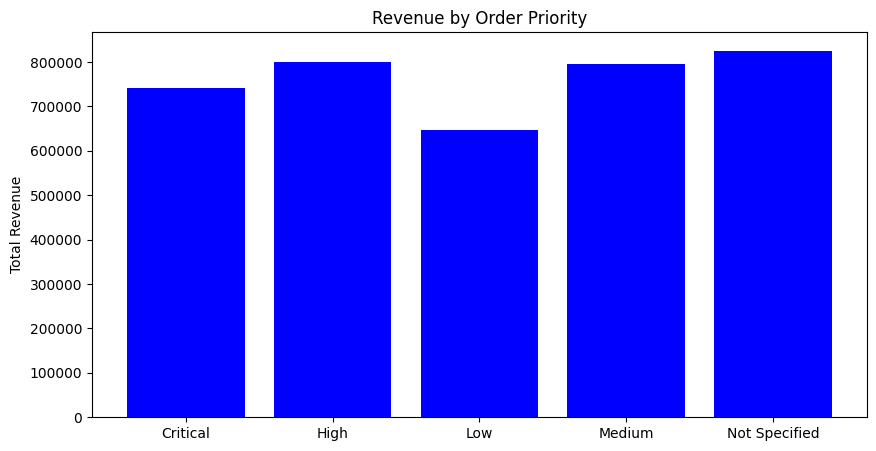

In [96]:
order_priority = df.groupby('Order Priority')['Order Total'].sum().reset_index()
plt.figure(figsize=(10,5))
plt.bar(order_priority['Order Priority'], order_priority['Order Total'],color = "blue")
plt.title('Revenue by Order Priority')
plt.ylabel('Total Revenue')
plt.show()

### 4. What is the average profit margin by product category?

In [85]:
Profit_margin = df.groupby('Product Category')['Profit Margin'].mean().reset_index()
Profit_margin

,Product Category,Profit Margin
0,Furniture,12.701953
1,Office Supplies,17.682609
2,Technology,20.423208


### 5. What is the most profitable product overall?

In [101]:
most_profitable = df.groupby('Product Name')['Total'].sum().sort_values(ascending=False)
most_profitable.idxmax()

'Cando PC940 Copier'

### 6. How many days does it usually take to ship an order?

In [87]:
data = df.copy()

In [88]:
df['Ship Duration'].mean()

Timedelta('-51 days +12:43:33.923227066')

### 7. Do longer shipping times impact profit margins?

In [93]:
df['Ship Duration'].corr(df['Profit Margin'])

np.float64(0.050458620500827146)

### 8. Which city brings in the highest revenue?

Highest_revenue = df.groupby('City')['Order Total'].sum().reset_index().sort_values(by='Order Total' ,ascending = False)
Highest_revenue

### 9. Which account manager generated the most revenue?

In [102]:
df.groupby('Account Manager')['Order Total'].sum().idxmax()

'Connor Betts'

### 10. Which shipping mode is most cost-effective (lowest avg. shipping)?

In [108]:
df.groupby('Ship Mode')['Ship Duration'].mean().reset_index().sort_values(by='Ship Duration' ,ascending = False)

,Ship Mode,Ship Duration
1,Express Air,-49 days +05:37:01.276595745
2,Regular Air,-51 days +07:55:35.172413793
0,Delivery Truck,-52 days +04:21:49.090909091


### 11. Do higher discounts reduce profits?

In [112]:
df['Discount %'].corr(df['Profit Margin'])

np.float64(-0.026044066258333182)

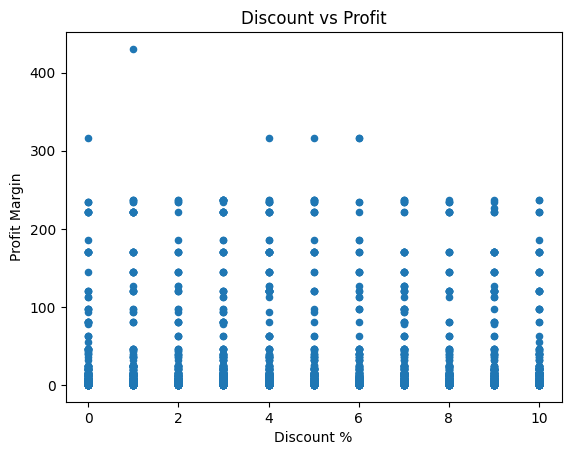

In [113]:
df.plot.scatter(x='Discount %', y='Profit Margin')
plt.title('Discount vs Profit')
plt.show()

### 12. Which state has the highest number of orders?


In [115]:
df['State'].value_counts().sort_values(ascending=False)

State
NSW    3584
VIC    1416
Name: count, dtype: int64

### 13. What is the average discount % across all orders?

In [116]:
df['Discount %'].mean()

np.float64(5.0338)

### 14. What is the average total spend per order?

In [127]:
df[['Cost Price','Shipping Cost']].mean().reset_index()

,index,0
0,Cost Price,20.394022
1,Shipping Cost,5.464932


### 15. . Are certain containers (e.g., Small Box, Wrap Bag) more profitable?

In [131]:
df.groupby('Product Container')['Profit Margin'].max().reset_index().sort_values(by='Profit Margin',ascending = False)

,Product Container,Profit Margin
3,Small Box,430.18
0,Jumbo Drum,316.03
4,Small Pack,316.03
2,Medium Box,237.05
5,Wrap Bag,237.05
1,Large Box,144.47
